PROBLEMA 2

a) Señal compuesta

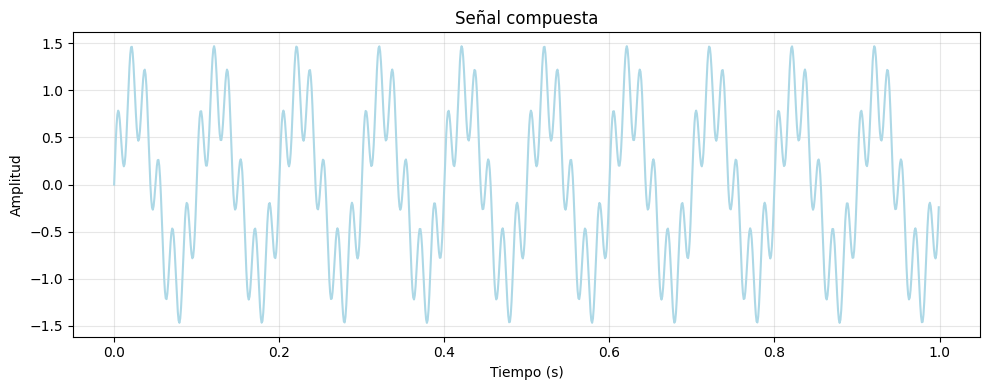

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import curve_fit

# Parámetros para la señal
f1, f2 = 10.0, 60.0          # frecuencias en Hz
Fs = 1024                    # frecuencia de muestreo (Hz)
N_plot = 1024                # número de muestras para los gráficos
t = np.linspace(0, 1, N_plot, endpoint=False)   # 1 segundo de duración

# Señal: sin(2π f1 t) + 0.5 sin(2π f2 t)
x = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

# Gráfico simple de la señal compuesta
plt.figure(figsize=(10, 4))
plt.plot(t, x, color='lightblue', linewidth=1.5)
plt.title("Señal compuesta")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

b) Transformada de Fourier discreta (DFT) con dos bucles for

In [2]:
def manual_dft(signal):
    """DFT usando dos bucles for (O(N^2))."""
    N = len(signal)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += signal[n] * np.exp( (-2j * np.pi * k * n) / N)
    return X

c) Gráfico: señal original (azul claro) y resultado de la DFT manual (púrpura)

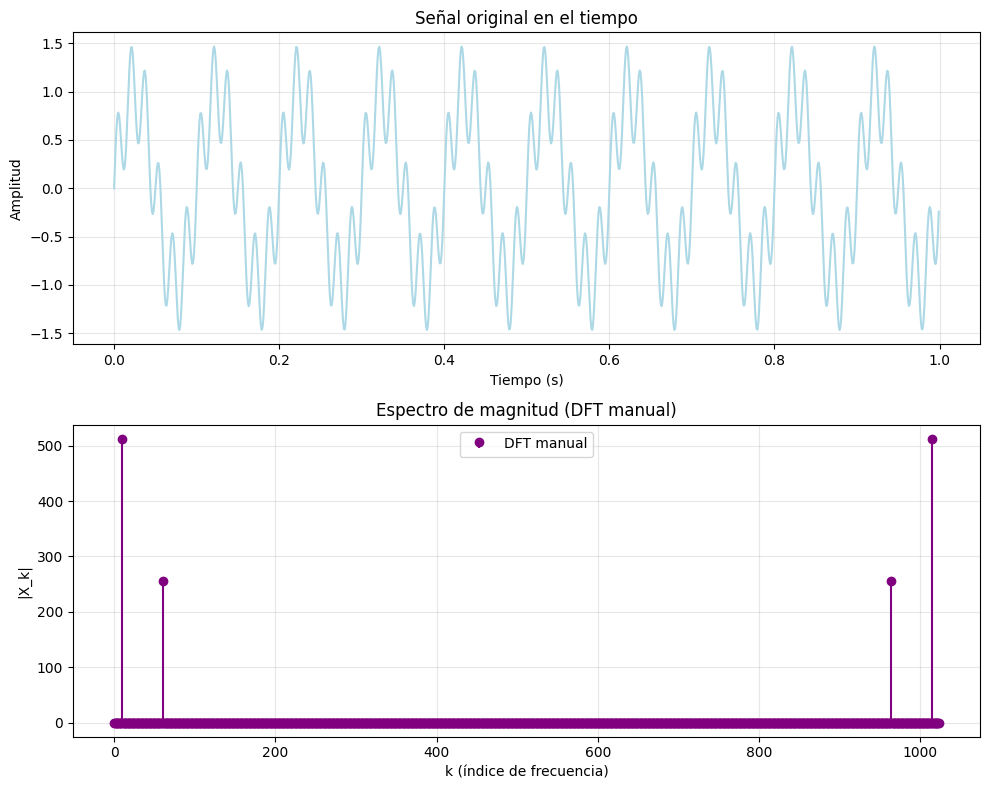

In [3]:
# Calcular DFT manual para la señal de N_plot puntos
X_manual = manual_dft(x)

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Subplot superior: señal original en el tiempo
ax1.plot(t, x, color='lightblue', linewidth=1.5)
ax1.set_title("Señal original en el tiempo")
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Amplitud")
ax1.grid(alpha=0.3)

# Subplot inferior: magnitud de la DFT manual (|X_k|)
k_vals = np.arange(N_plot)
magnitude_manual = np.abs(X_manual)
ax2.stem(k_vals, magnitude_manual, linefmt='purple', markerfmt='purple', basefmt=' ', label='DFT manual')
ax2.set_title("Espectro de magnitud (DFT manual)")
ax2.set_xlabel("k (índice de frecuencia)")
ax2.set_ylabel("|X_k|")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

d) Usando FFT de numpy y comparandola en un mismo gráfico con la versión analítica

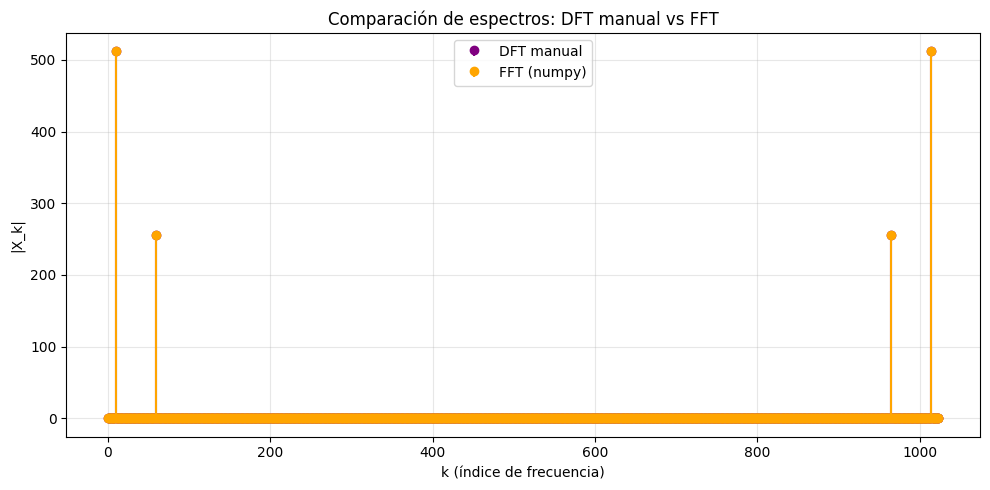

Diferencia máxima entre DFT manual y FFT: 1.2591e-10



In [4]:
X_fft = np.fft.fft(x)          # FFT de numpy

# Gráfico con ambos espectros: DFT manual (púrpura) y FFT (naranja)
plt.figure(figsize=(10, 5))
plt.stem(k_vals, magnitude_manual, linefmt='purple', markerfmt='purple', basefmt=' ', label='DFT manual')
plt.stem(k_vals, np.abs(X_fft), linefmt='orange', markerfmt='orange', basefmt=' ', label='FFT (numpy)')
plt.title("Comparación de espectros: DFT manual vs FFT")
plt.xlabel("k (índice de frecuencia)")
plt.ylabel("|X_k|")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Verificar que ambas transformadas son idénticas (dentro del error numérico)
max_diff = np.max(np.abs(X_manual - X_fft))
print(f"Diferencia máxima entre DFT manual y FFT: {max_diff:.4e}\n")

e) Medición de tiempos para N = 10^2, 10^3, 10^4, 10^5

In [ ]:
def manual_dft(signal):
    """DFT usando dos bucles for (O(N^2))."""
    N = len(signal)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += signal[n] * np.exp(-2j * np.pi * k * n / N)
    return X

# Tamaños de señal a evaluar
N_values = [100, 1000, 10000, 100000]
times_dft = []
times_fft = []

print("\n===== Medición de tiempos para DFT manual y FFT =====")
for N in N_values:
    print(f"\nProcesando N = {N} ...")
    # Generar señal de prueba (dos senos)
    t = np.linspace(0, 1, N, endpoint=False)
    x = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 60 * t)
    
    # Medir DFT manual
    start = time.perf_counter()
    _ = manual_dft(x)
    elapsed_dft = time.perf_counter() - start
    times_dft.append(elapsed_dft)
    
    # Medir FFT
    start = time.perf_counter()
    _ = np.fft.fft(x)
    elapsed_fft = time.perf_counter() - start
    times_fft.append(elapsed_fft)
    
    print(f"  DFT manual: {elapsed_dft:.4f} s")
    print(f"  FFT:        {elapsed_fft:.4f} s")

# Mostrar tabla de resultados
print("\n===== Resumen de tiempos (segundos) =====")
print(f"{'N':<8} {'DFT manual':<15} {'FFT':<15}")
for i, N in enumerate(N_values):
    print(f"{N:<8} {times_dft[i]:<15.4f} {times_fft[i]:<15.4f}")


===== Medición de tiempos para DFT manual y FFT =====

Procesando N = 100 ...
  DFT manual: 0.0182 s
  FFT:        0.0001 s

Procesando N = 1000 ...
  DFT manual: 1.6357 s
  FFT:        0.0002 s

Procesando N = 10000 ...
  DFT manual: 144.2179 s
  FFT:        0.0005 s

Procesando N = 100000 ...
  DFT manual: 17353.0756 s
  FFT:        0.0036 s

===== Resumen de tiempos (segundos) =====
N        DFT manual      FFT            
100      0.0182          0.0001         
1000     1.6357          0.0002         
10000    144.2179        0.0005         
100000   17353.0756      0.0036         


f) Gráfico tiempo vs N (escala lineal)

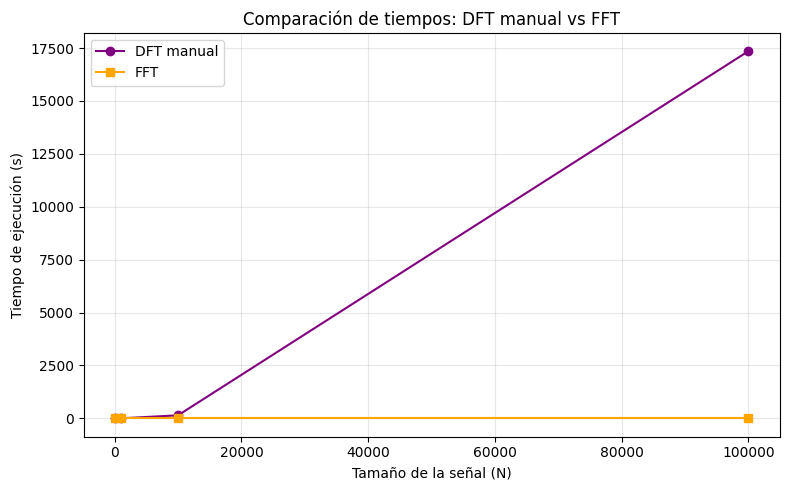

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(N_values, times_dft, 'o-', color='purple', label='DFT manual')
plt.plot(N_values, times_fft, 's-', color='orange', label='FFT')
plt.xlabel('Tamaño de la señal (N)')
plt.ylabel('Tiempo de ejecución (s)')
plt.title('Comparación de tiempos: DFT manual vs FFT')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

g) Gráfico en escala log‑log y estimación de exponentes


===== Estimación de exponentes de escalamiento (log‑log) =====
DFT manual: tiempo ~ 1.81e-06 * N^1.9887  (exponente ≈ 1.9887)
FFT:        tiempo ~ 8.92e-06 * N^0.4815  (exponente ≈ 0.4815)


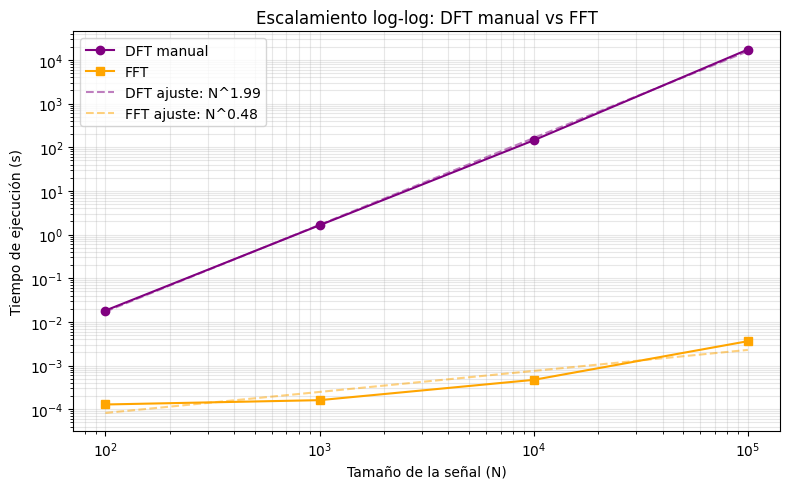

In [11]:
# Función para ajustar una recta a datos log-log
def fit_power_law(N, times):
    """Ajusta times = a * N^b, devuelve b (exponente) y a."""
    logN = np.log10(N)
    logT = np.log10(times)
    coefs = np.polyfit(logN, logT, 1)  # pendiente = b, intercepto = log10(a)
    b = coefs[0]
    a = 10 ** coefs[1]
    return a, b

# Ajuste para DFT manual
a_dft, b_dft = fit_power_law(N_values, times_dft)
# Ajuste para FFT
a_fft, b_fft = fit_power_law(N_values, times_fft)

print("\n===== Estimación de exponentes de escalamiento (log‑log) =====")
print(f"DFT manual: tiempo ~ {a_dft:.2e} * N^{b_dft:.4f}  (exponente ≈ {b_dft:.4f})")
print(f"FFT:        tiempo ~ {a_fft:.2e} * N^{b_fft:.4f}  (exponente ≈ {b_fft:.4f})")

# Graficar en escala log‑log
plt.figure(figsize=(8, 5))
plt.loglog(N_values, times_dft, 'o-', color='purple', label='DFT manual')
plt.loglog(N_values, times_fft, 's-', color='orange', label='FFT')
# Graficar las curvas ajustadas
N_fit = np.logspace(np.log10(min(N_values)), np.log10(max(N_values)), 100)
plt.loglog(N_fit, a_dft * N_fit**b_dft, '--', color='purple', alpha=0.5, label=f'DFT ajuste: N^{b_dft:.2f}')
plt.loglog(N_fit, a_fft * N_fit**b_fft, '--', color='orange', alpha=0.5, label=f'FFT ajuste: N^{b_fft:.2f}')
plt.xlabel('Tamaño de la señal (N)')
plt.ylabel('Tiempo de ejecución (s)')
plt.title('Escalamiento log‑log: DFT manual vs FFT')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

h) Determinar N donde FFT es 100 veces más rápida que DFT

In [13]:
# Resolvemos: a_dft * N^b_dft >= 100 * a_fft * N^b_fft
# => (a_dft / (100 * a_fft)) >= N^(b_fft - b_dft)
# => N <= ... (cuidado con signo del exponente)
# Como b_dft (≈2) > b_fft (≈1), el exponente (b_fft - b_dft) es negativo.
# Despejamos N:

if b_dft > b_fft:
    # La desigualdad se invierte al despejar
    ratio_const = a_dft / (100 * a_fft)
    exponent = b_fft - b_dft   # negativo
    # ratio_const >= N^exponent => N >= (ratio_const)^(1/exponent)
    N_threshold = ratio_const ** (1.0 / exponent)
else:
    # En caso teórico improbable, usamos otro método
    N_threshold = 1e6

print("\n===== Umbral donde FFT es 100 veces más rápida =====")
print(f"Según los ajustes, la FFT es al menos 100 veces más rápida que la DFT manual cuando N >= {N_threshold:.0f}")

# También podemos mostrar la relación de tiempos en los puntos medidos
print("\nRelación de tiempos (DFT / FFT) en los puntos evaluados:")
for i, N in enumerate(N_values):
    ratio = times_dft[i] / times_fft[i]
    print(f"  N = {N:5d} : DFT/FFT = {ratio:.2f}")


===== Umbral donde FFT es 100 veces más rápida =====
Según los ajustes, la FFT es al menos 100 veces más rápida que la DFT manual cuando N >= 61

Relación de tiempos (DFT / FFT) en los puntos evaluados:
  N =   100 : DFT/FFT = 141.83
  N =  1000 : DFT/FFT = 10172.07
  N = 10000 : DFT/FFT = 307304.25
  N = 100000 : DFT/FFT = 4809344.17
